# Telco Customer Churn — Data Wrangling Notebook

**Author:** Allison Schiltz    

> Dataset reference: *Telco Customer Churn* (Kaggle).
https://www.kaggle.com/datasets/blastchar/telco-customer-churn/code


## 0. Environment & Imports

In [41]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Warning management
import warnings
from pandas.errors import SettingWithCopyWarning

# Reproducibility seed (if needed)
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Display options (tweak as needed)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Environment ready | pandas", pd.__version__, "| numpy", np.__version__)

Environment ready | pandas 2.3.3 | numpy 2.3.4


## 1. Load Raw Data


In [42]:
telco_raw = pd.read_csv('/Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/data/raw/Telco-Customer-Churn-Blastchar.csv')

telco_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
# Make a copy for wrangling
telco_wrangling = telco_raw.copy()

## 2. Initial Inspection

In [44]:
print('HEAD:\n', telco_wrangling.head())
print('\nTAIL:\n', telco_wrangling.tail())
print('\nSAMPLE:\n', telco_wrangling.sample(n=5, random_state=SEED))
print('\nSHAPE:\n', telco_wrangling.shape)
print('\nINFO:')
telco_wrangling.info()
print('\nDESCRIBE:\n', telco_wrangling.describe().T)
print('\nNULL COUNTS:\n', telco_wrangling.isnull().sum().sort_values(ascending=False))

HEAD:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity  \
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No   
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes                No             DSL            Yes   
3  7795-CFOCW    Male              0      No         No      45           No  No phone service             DSL            Yes   
4  9237-HQITU  Female              0      No         No       2          Yes                No     Fiber optic             No   

  OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  \
0          Yes               No          No          No              No  Month-to-m

## 3. Draft Data Dictionary (from raw)


In [45]:
telco_data_dict_raw = pd.read_csv('/Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/references/telco_raw_data_dictionary.csv')

print(telco_data_dict_raw)

         Column Name Data Type  Unique Values                                    Expected Values  \
0         customerID    object           7043  ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-...   
1             gender    object              2                                  ['Female' 'Male']   
2      SeniorCitizen     int64              2                                              [0 1]   
3            Partner    object              2                                       ['Yes' 'No']   
4         Dependents    object              2                                       ['No' 'Yes']   
5             tenure     int64             73                                   [ 1 34  2 45  8]   
6       PhoneService    object              2                                       ['No' 'Yes']   
7      MultipleLines    object              3                    ['No phone service' 'No' 'Yes']   
8    InternetService    object              3                         ['DSL' 'Fiber optic' 'No']   


## 4. Data Quality Audit

### 4.1 Missingness

In [46]:
# Check for missing values -- NaN or None
missing = pd.concat([telco_wrangling.isnull().sum(), 100 * telco_wrangling.isnull().mean()], axis=1)
missing.columns=['count', '%']
missing.sort_values(by='count', ascending=False)

,count,%
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [47]:
# Check for blank or whitespace-only strings in object columns
for col in telco_wrangling.select_dtypes(include='object'):
    n_blanks = (telco_wrangling[col].str.strip() == '').sum()
    if n_blanks > 0:
        print(f"{col}: {n_blanks} blank/whitespace values")

TotalCharges: 11 blank/whitespace values


In [48]:
# Check for placeholder values
placeholders = ['NA', 'N/A', 'null', 'None', '?', '-']
for col in telco_wrangling.columns:
    for val in placeholders:
        n = (telco_wrangling[col] == val).sum()
        if n > 0:
            print(f"{col}: {n} occurrences of '{val}'")

In [49]:
# Check for constant columns
for col in telco_wrangling.columns:
    if telco_wrangling[col].nunique(dropna=False) == 1:
        print(f"{col} has only one unique value: {telco_wrangling[col].unique()}")

### 4.2 Duplicates

In [50]:
# number unique values
telco_wrangling.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [51]:
# Find duplicate rows
duplicates = telco_wrangling[telco_wrangling.duplicated()]

# Display duplicate rows (if any)
print(duplicates)

# Count duplicate rows
print(telco_wrangling.duplicated().sum())

Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []
0


In [52]:
# View unique values per column
for col in telco_wrangling.columns:
    if telco_wrangling[col].nunique() < 5:
        print(telco_wrangling[col].value_counts(), "\n")

gender
Male      3555
Female    3488
Name: count, dtype: int64 

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64 

Partner
No     3641
Yes    3402
Name: count, dtype: int64 

Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64 

TechSupport
No                     3473
Yes                    2044
No internet ser

### 4.3 Data Types and Conversion

In [53]:
# coerce TotalCharges to numeric
telco_wrangling['TotalCharges'] = pd.to_numeric(telco_wrangling['TotalCharges'], errors='coerce')

In [54]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'Churn'
]
for col in cat_cols:
    telco_wrangling[col] = telco_wrangling[col].astype('category')

In [55]:
# convert SeniorCitizen values to Yes/No from 1/0 for clarity
telco_wrangling['SeniorCitizen'] = telco_wrangling['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

In [56]:
telco_wrangling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 n

### 4.4 Value Ranges & Invariants

In [57]:
print('\nDESCRIBE:\n', telco_wrangling.describe().T)
print('\nNULL COUNTS:\n', telco_wrangling.isnull().sum().sort_values(ascending=False))


DESCRIBE:
                  count         mean          std    min     25%       50%        75%      max
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.000    55.0000    72.00
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.350    89.8500   118.75
TotalCharges    7032.0  2283.300441  2266.771362  18.80  401.45  1397.475  3794.7375  8684.80

NULL COUNTS:
 TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64


In [58]:
# check categorical domains
for col in cat_cols:
    print(telco_wrangling[col].value_counts(), '\n')

gender
Male      3555
Female    3488
Name: count, dtype: int64 

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64 

Partner
No     3641
Yes    3402
Name: count, dtype: int64 

Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64 

TechSupport
No                     3473
Yes                    2044
No internet

## 5. Missing Values — Strategy & Implementation
- TotalCharges = NaN represents customers who have just signed up for the service, i.e, their tenure is 0 months.
- TotalCharges = NaN were dropped. Because none of them had churned, these rows don't contribute to the churn analysis.

In [59]:
# Check tenure and Churn values for null TotalCharges
telco_wrangling.loc[telco_wrangling['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [60]:
# Drop rows with null TotalCharges
telco_wrangling = telco_wrangling.dropna(subset=['TotalCharges'])

In [61]:
# Check that drop worked as expected
telco_wrangling.loc[telco_wrangling['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


## 6. Categorical Labels — Standardization
- Ensure consistent data types and category orders.

In [62]:
# Print all unique values for each categorical column
for col in cat_cols:
    print(f"{col}: {list(telco_wrangling[col].unique())}")

gender: ['Female', 'Male']
SeniorCitizen: ['No', 'Yes']
Partner: ['Yes', 'No']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No phone service', 'No', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'Yes', 'No internet service']
OnlineBackup: ['Yes', 'No', 'No internet service']
DeviceProtection: ['No', 'Yes', 'No internet service']
TechSupport: ['No', 'Yes', 'No internet service']
StreamingTV: ['No', 'Yes', 'No internet service']
StreamingMovies: ['No', 'Yes', 'No internet service']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['Yes', 'No']
PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn: ['No', 'Yes']


## 7. Outliers & Impossible Values
- Check for outliers, impossible values, and unusual patterns
No outliers, impossible values, or unusual patterns were found 
- Phone service was flagged as imbalanced


NUMERIC SUMMARY (extended percentiles)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
tenure,7032.0,32.421786,24.545260,1.00,1.0,1.000,9.0000,29.000,55.0000,72.0000,72.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,19.2,19.650,35.5875,70.350,89.8625,107.4225,114.7345,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,19.9,49.605,401.4500,1397.475,3794.7375,6923.5900,8039.8830,8684.80


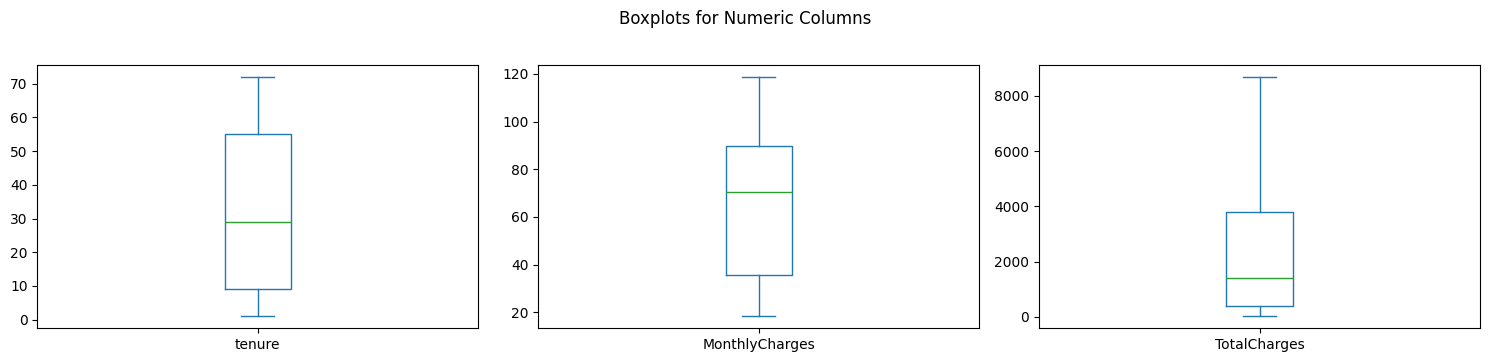

Numeric columns with any negative values: None

IQR outlier counts per numeric column:
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

gender value counts:
gender
Male      3549
Female    3483
Name: count, dtype: int64

SeniorCitizen value counts:
SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64

Partner value counts:
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Dependents value counts:
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

PhoneService value counts:
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

MultipleLines value counts:
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

InternetService value counts:
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

OnlineSecurity value counts:
OnlineSecurity
No                     3497
Yes                    2015
No internet service    15

In [63]:
# Outliers, impossible values, and unusual patterns
# ---------------------------------------------------------------

import math
import matplotlib.pyplot as plt

# 1) Numeric overview (with extra percentiles)
numeric_cols = telco_wrangling.select_dtypes(include=[np.number]).columns
print("NUMERIC SUMMARY (extended percentiles)")
display(telco_wrangling[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

# 2) Quick visuals: per-column boxplots
if len(numeric_cols) > 0:
    n_cols = 3
    n_rows = math.ceil(len(numeric_cols) / n_cols)
    telco_wrangling[numeric_cols].plot(kind='box', subplots=True,
        layout=(n_rows, n_cols), figsize=(5*n_cols, 3.5*n_rows), sharex=False, sharey=False)
    plt.suptitle('Boxplots for Numeric Columns', y=1.02)
    plt.tight_layout()
    plt.show()

# 3) Impossible values: negative checks for numeric columns
negatives_any = (telco_wrangling[numeric_cols] < 0).any() if len(numeric_cols) else pd.Series(dtype=bool)
bad_negative_cols = negatives_any[negatives_any].index.tolist()
print("Numeric columns with any negative values:", bad_negative_cols if bad_negative_cols else "None")

# 4) IQR-based outlier counts (per column)
if len(numeric_cols) > 0:
    q1 = telco_wrangling[numeric_cols].quantile(0.25)
    q3 = telco_wrangling[numeric_cols].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (telco_wrangling[numeric_cols] < lower) | (telco_wrangling[numeric_cols] > upper)
    outlier_counts = outlier_mask.sum().sort_values(ascending=False)
    print("\nIQR outlier counts per numeric column:")
    print(outlier_counts)
    any_outlier_rows = outlier_mask.any(axis=1)
    if any_outlier_rows.any():
        cols_to_show = ['customerID'] + list(numeric_cols) if 'customerID' in telco_wrangling.columns else list(numeric_cols)
        print("\nExample rows with any numeric outlier (first 10):")
        display(telco_wrangling.loc[any_outlier_rows, cols_to_show].head(10))

# 5) Categorical sanity: compact value counts for small-cardinality columns
cat_cols = telco_wrangling.select_dtypes(include=['category', 'object']).columns
for col in cat_cols:
    vc = telco_wrangling[col].value_counts(dropna=False)
    if vc.size <= 10:
        print(f"\n{col} value counts:")
        print(vc)

# 6) Logical consistency checks (business rules)
internet_dependent = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
if 'InternetService' in telco_wrangling.columns and set(internet_dependent).issubset(telco_wrangling.columns):
    mask_internet_none = telco_wrangling['InternetService'] == 'No'
    mask_addon_yes = telco_wrangling[internet_dependent].eq('Yes').any(axis=1)
    contradictions_internet = telco_wrangling[mask_internet_none & mask_addon_yes]
    print(f"\nRows with InternetService='No' but an internet add-on is 'Yes': {len(contradictions_internet)}")
    if len(contradictions_internet) > 0:
        display(contradictions_internet[['InternetService'] + internet_dependent].head(10))

if 'PhoneService' in telco_wrangling.columns and 'MultipleLines' in telco_wrangling.columns:
    contradictions_phone = telco_wrangling[(telco_wrangling['PhoneService'] == 'No') & (telco_wrangling['MultipleLines'] == 'Yes')]
    print(f"\nRows with PhoneService='No' but MultipleLines='Yes': {len(contradictions_phone)}")
    if len(contradictions_phone) > 0:
        display(contradictions_phone[['PhoneService','MultipleLines']].head(10))

# 7) High-cardinality and constant columns (useful hints for modeling)
nunique = telco_wrangling.nunique(dropna=False)
high_card = nunique[nunique > 50].sort_values(ascending=False)
constant = nunique[nunique == 1]
print("\nHigh-cardinality columns (>50 unique):")
print(high_card if not high_card.empty else "None")
print("\nConstant columns:")
print(constant if not constant.empty else "None")


NUMERIC SUMMARY (p1, p5, quartiles, p95, p99)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
tenure,7032.0,32.421786,24.545260,1.00,1.0,1.000,9.0000,29.000,55.0000,72.0000,72.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,19.2,19.650,35.5875,70.350,89.8625,107.4225,114.7345,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,19.9,49.605,401.4500,1397.475,3794.7375,6923.5900,8039.8830,8684.80


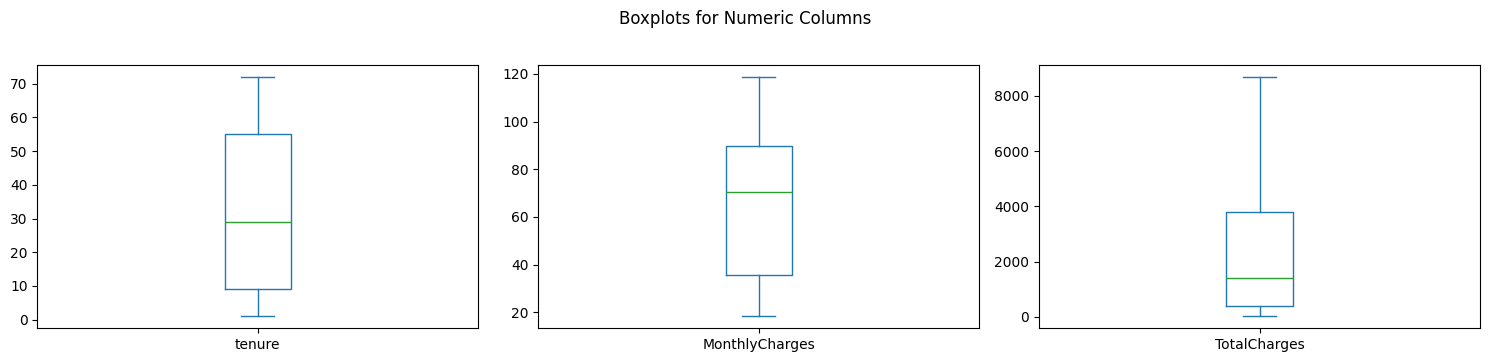


IQR outlier counts per numeric column:
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [64]:
# Slim screening version for future reference: describe + boxplots + IQR outlier counts
# ---------------------------------------------------------------
# Use this if you want a shorter, faster pass without extra checks.

import math
import matplotlib.pyplot as plt

# Numeric summary with extended percentiles
numeric_cols = telco_wrangling.select_dtypes(include=[np.number]).columns
print("NUMERIC SUMMARY (p1, p5, quartiles, p95, p99)")
display(telco_wrangling[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

# Boxplots per numeric column
if len(numeric_cols) > 0:
    n_cols = 3
    n_rows = math.ceil(len(numeric_cols) / n_cols)
    telco_wrangling[numeric_cols].plot(kind='box', subplots=True,
        layout=(n_rows, n_cols), figsize=(5*n_cols, 3.5*n_rows), sharex=False, sharey=False)
    plt.suptitle('Boxplots for Numeric Columns', y=1.02)
    plt.tight_layout()
    plt.show()

# IQR-based outlier counts
if len(numeric_cols) > 0:
    q1 = telco_wrangling[numeric_cols].quantile(0.25)
    q3 = telco_wrangling[numeric_cols].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts = ((telco_wrangling[numeric_cols] < lower) | (telco_wrangling[numeric_cols] > upper)).sum().sort_values(ascending=False)
    print("\nIQR outlier counts per numeric column:")
    print(outlier_counts)


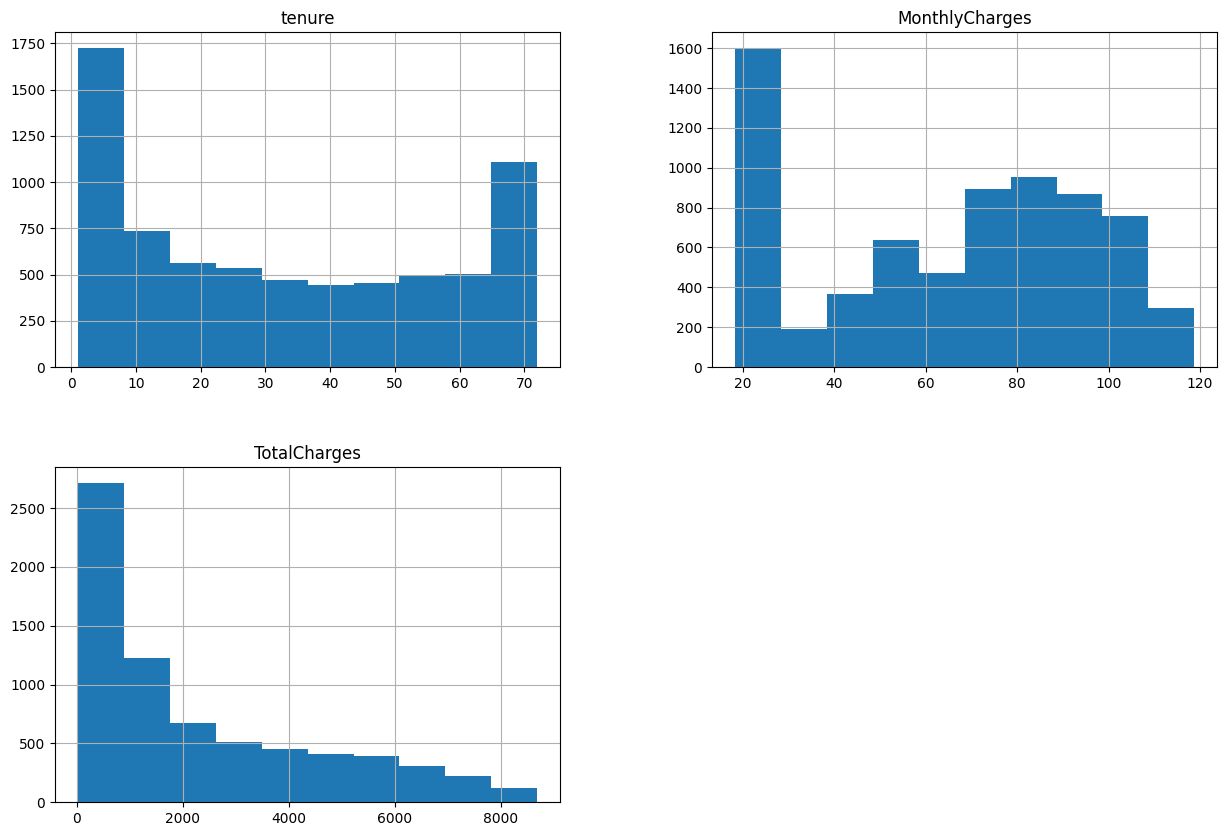

In [65]:
# Quick histograms for all numeric columns
%matplotlib inline
telco_wrangling.hist(figsize=(15, 10))
plt.show()

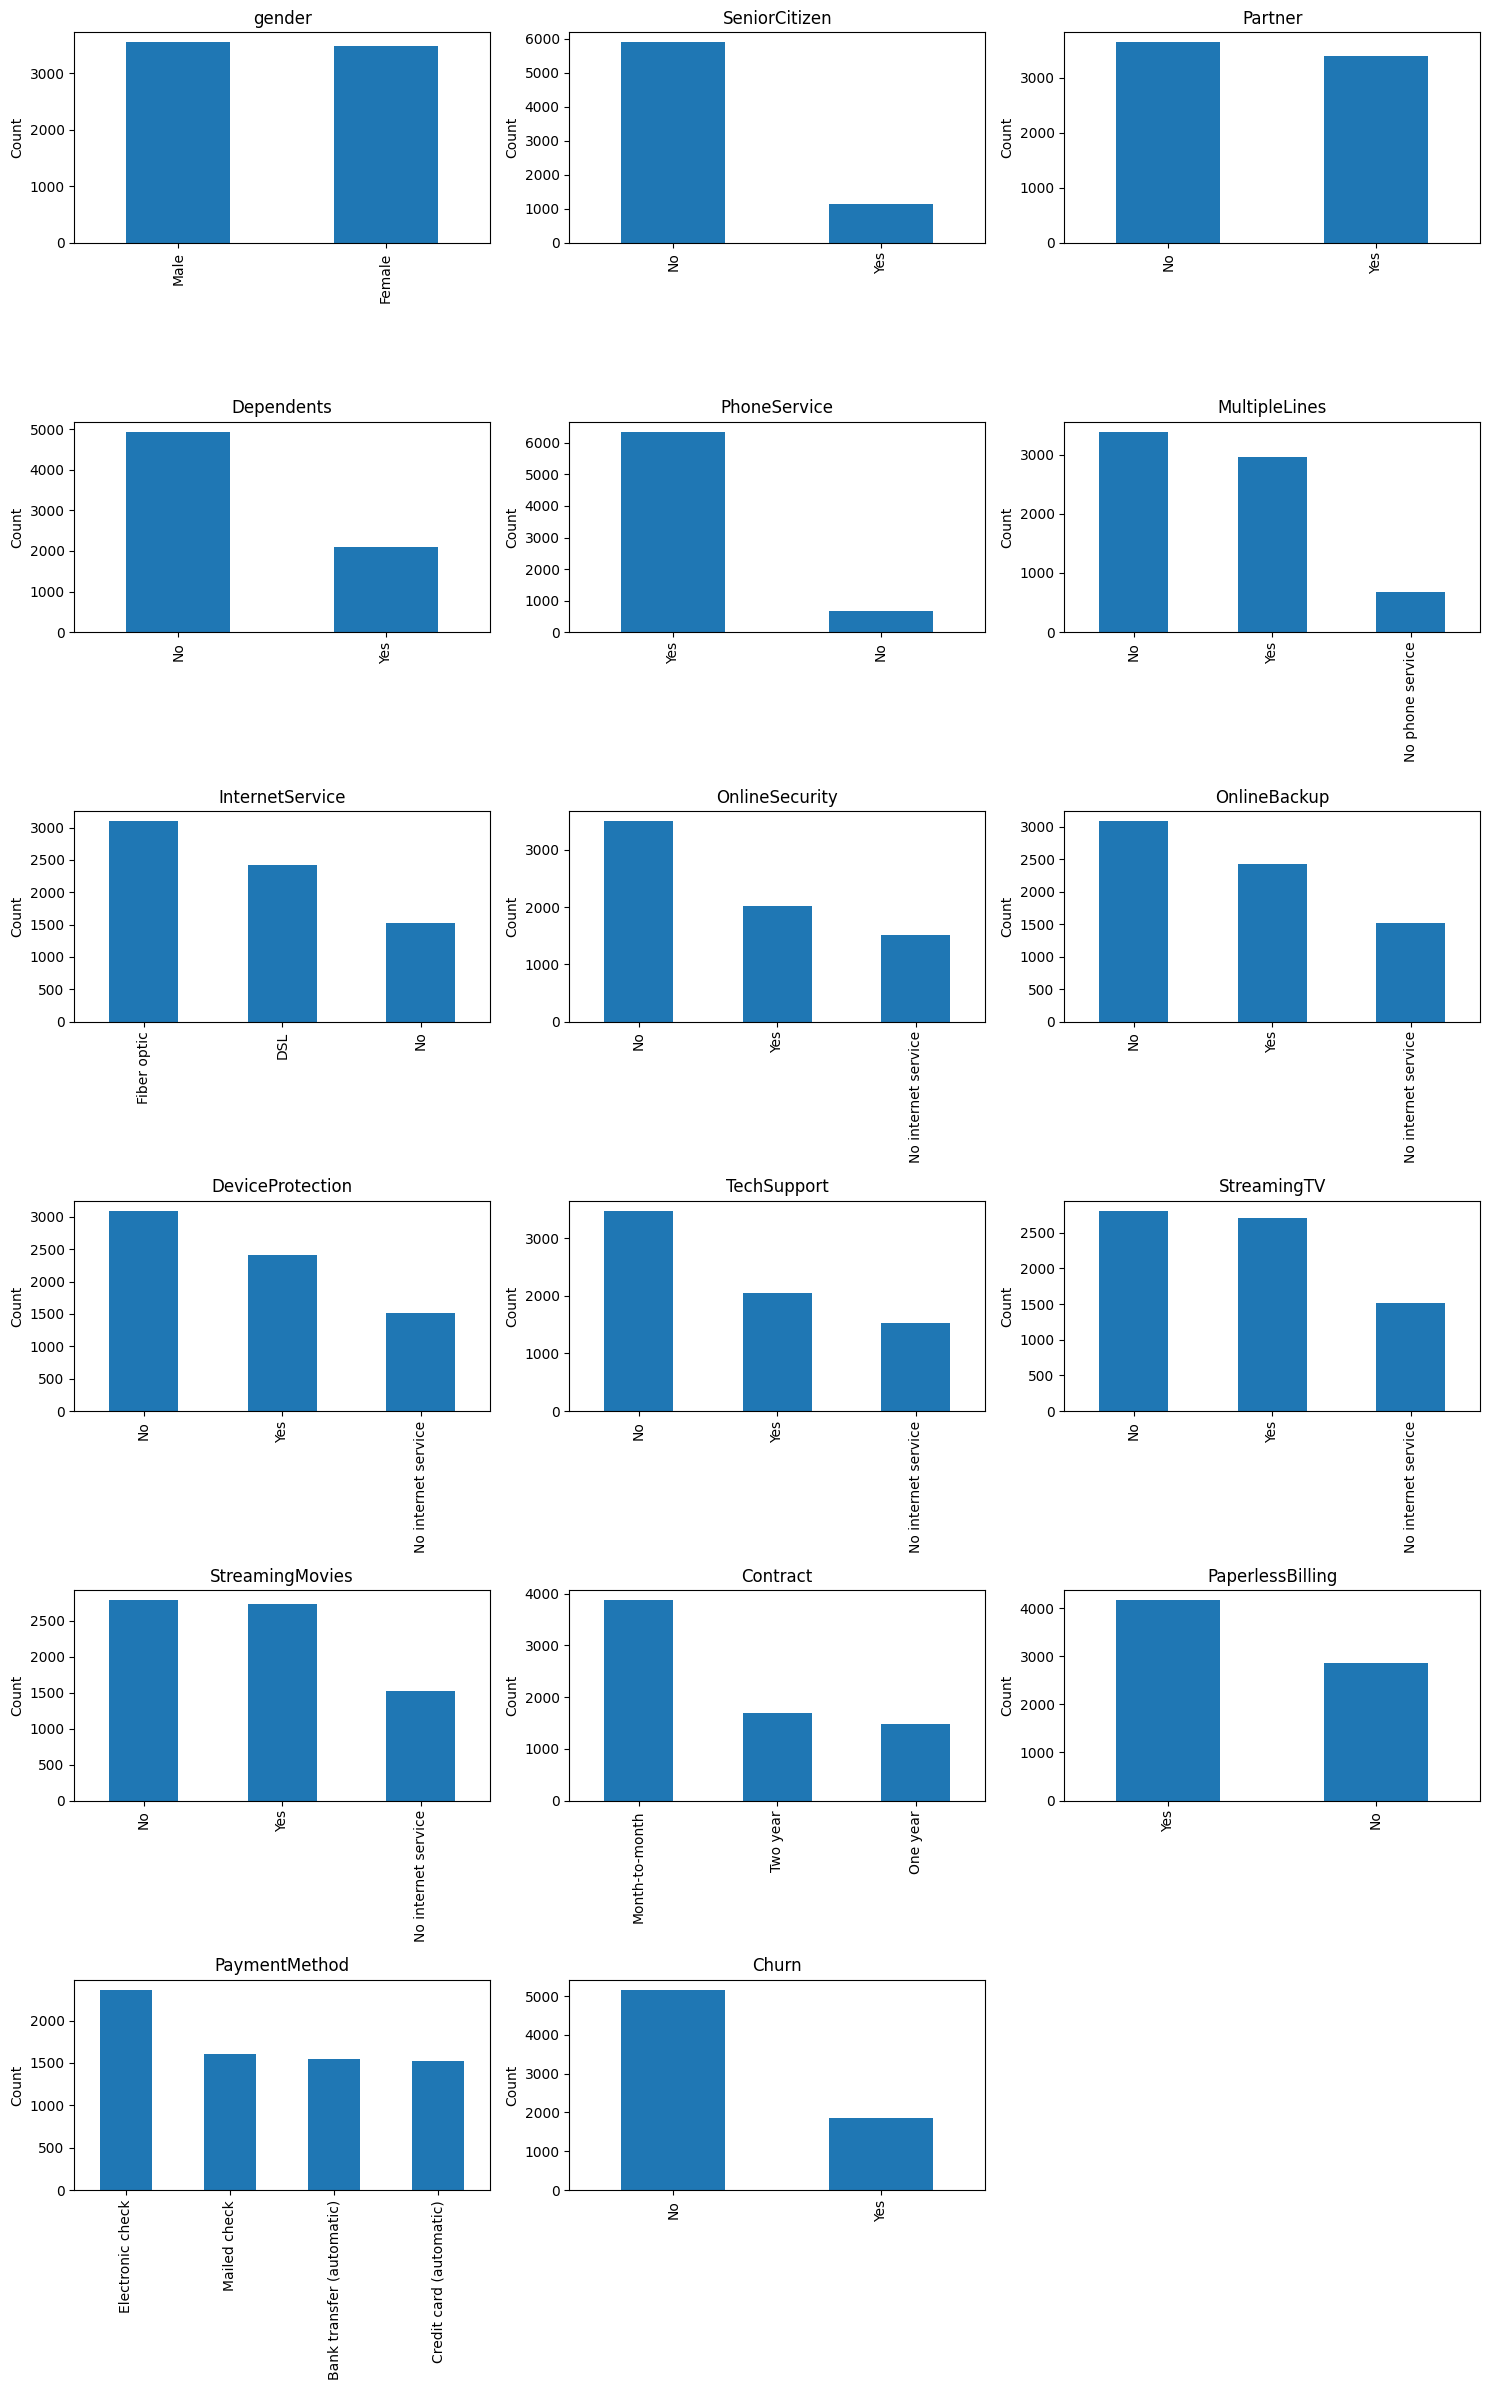

In [66]:
# Histograms for all categorical columns
# List of categorical columns
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'Churn'
]

n_cols = 3  # Number of columns in the grid
n_rows = math.ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    telco_wrangling[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Engineered Features for EDA


In [67]:
# Print list of features for reference
for number, column in enumerate(telco_wrangling.columns.tolist()):
    print(number + 1, column)

1 customerID
2 gender
3 SeniorCitizen
4 Partner
5 Dependents
6 tenure
7 PhoneService
8 MultipleLines
9 InternetService
10 OnlineSecurity
11 OnlineBackup
12 DeviceProtection
13 TechSupport
14 StreamingTV
15 StreamingMovies
16 Contract
17 PaperlessBilling
18 PaymentMethod
19 MonthlyCharges
20 TotalCharges
21 Churn


In [68]:
# --- Engineered Features ---
# 1. Tenure group (bins)
tenure_bins = [0, 6, 12, 24, 48, np.inf]
tenure_labels = ['0-6', '7-12', '13-24', '25-48', '49+']
telco_wrangling['tenure_group_eng'] = pd.cut(telco_wrangling['tenure'], bins=tenure_bins, labels=tenure_labels, right=True, include_lowest=True)

# 2. Total services (count of Yes across service columns)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
def count_services(row):
    return sum(row[col] == 'Yes' for col in service_cols if col in row)
telco_wrangling['total_services_eng'] = telco_wrangling.apply(count_services, axis=1)

# 3. Monthly charges bins
monthly_bins = [0, 35, 70, np.inf]
monthly_labels = ['Low', 'Medium', 'High']
telco_wrangling['monthly_charges_bin_eng'] = pd.cut(telco_wrangling['MonthlyCharges'], bins=monthly_bins, labels=monthly_labels, right=False)

# 4. Contract type: month-to-month vs. long-term
telco_wrangling['is_month_to_month_eng'] = telco_wrangling['Contract'].apply(lambda x: 'Yes' if x == 'Month-to-month' else 'No')
telco_wrangling['is_month_to_month_eng'] = telco_wrangling['is_month_to_month_eng'].astype('category')


# 5. Tenure x contract interaction: short tenure & month-to-month
telco_wrangling['short_tenure_month_to_month_eng'] = ((telco_wrangling['tenure'] <= 12) & (telco_wrangling['is_month_to_month_eng'] == 'Yes')).astype('category')

#6. Collapse streaming services into single flag
telco_wrangling['has_streaming_eng'] = (
    ((telco_wrangling['StreamingTV'] == 'Yes') | (telco_wrangling['StreamingMovies'] == 'Yes'))
    .map({True: 'Yes', False: 'No'})
)
telco_wrangling['has_streaming_eng'] = pd.Categorical(telco_wrangling['has_streaming_eng'], categories=['No', 'Yes'])

In [69]:
telco_wrangling[['tenure_group_eng', 'total_services_eng', 'monthly_charges_bin_eng', 'is_month_to_month_eng', 'short_tenure_month_to_month_eng', 'has_streaming_eng']].head()

,tenure_group_eng,total_services_eng,monthly_charges_bin_eng,is_month_to_month_eng,short_tenure_month_to_month_eng,has_streaming_eng
0,0-6,1,Low,Yes,True,No
1,25-48,3,Medium,No,False,No
2,0-6,3,Medium,Yes,True,No
3,25-48,3,Medium,No,False,No
4,0-6,1,High,Yes,True,No


## 9. Finalize Clean Dataset
- Re-run `info()` and missingness checks
- Create histograms of engineered columns to confirm data quality
- Save cleaned data set
- Write data dictionary for the clean dataset.

In [70]:
# Re-run quality checks on the data

print('\nSHAPE:\n', telco_wrangling.shape)
print('\nINFO:')
telco_wrangling.info()
print('\nDESCRIBE:\n', telco_wrangling.describe().T)
null_count = [null_count for null_count in telco_wrangling.isnull().sum() if null_count > 0]
print(f"\nColumns with null values: {null_count if null_count else 'None'}")


SHAPE:
 (7032, 27)

INFO:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   customerID                       7032 non-null   object  
 1   gender                           7032 non-null   category
 2   SeniorCitizen                    7032 non-null   category
 3   Partner                          7032 non-null   category
 4   Dependents                       7032 non-null   category
 5   tenure                           7032 non-null   int64   
 6   PhoneService                     7032 non-null   category
 7   MultipleLines                    7032 non-null   category
 8   InternetService                  7032 non-null   category
 9   OnlineSecurity                   7032 non-null   category
 10  OnlineBackup                     7032 non-null   category
 11  DeviceProtection                 7032 non-null 

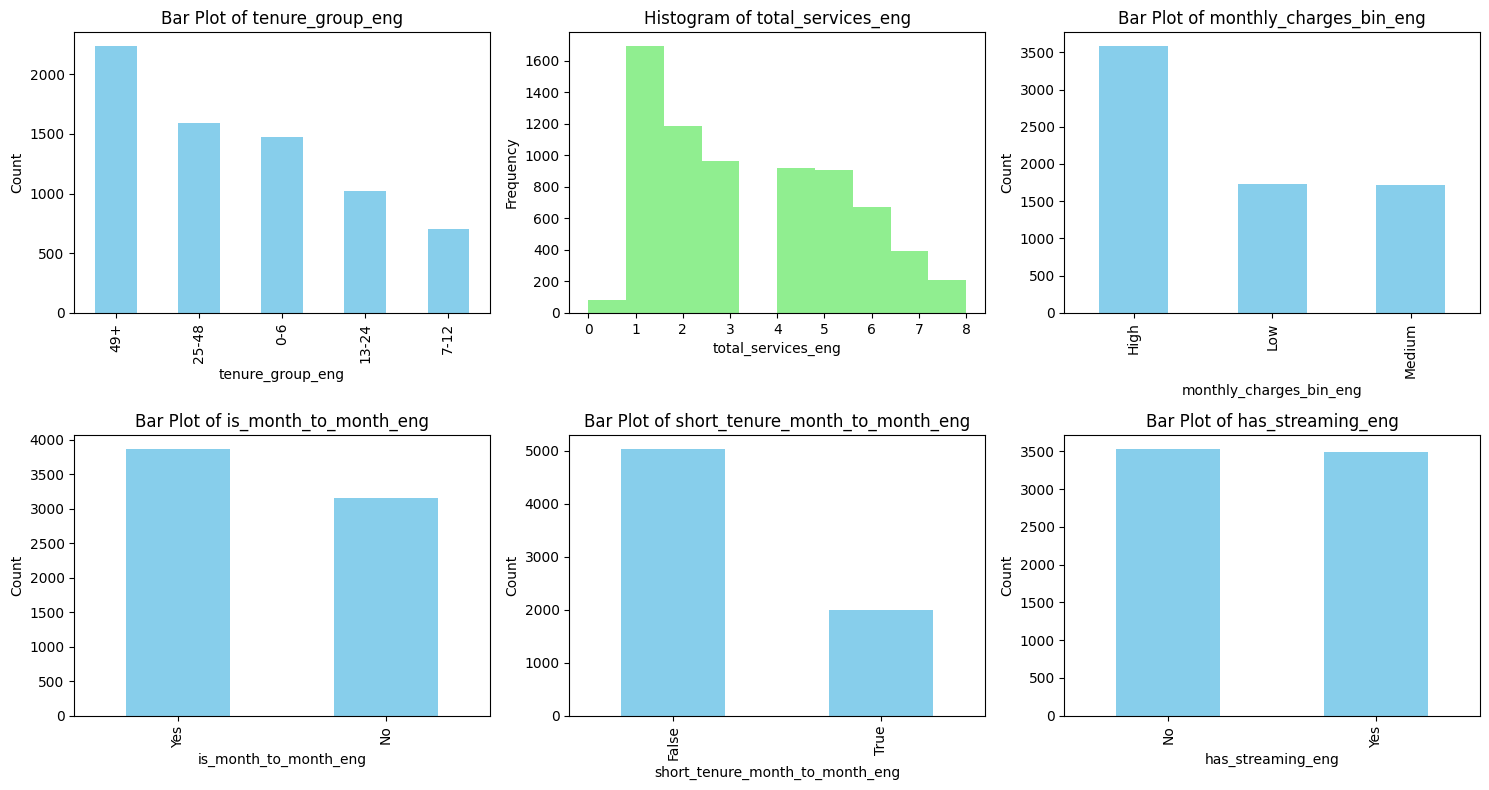

In [71]:
# Visualize engineered feature distributions in a compact subplot grid
engineered_cols = ['tenure_group_eng', 'total_services_eng', 'monthly_charges_bin_eng', 'is_month_to_month_eng', 'short_tenure_month_to_month_eng', 'has_streaming_eng']

import math
import matplotlib.pyplot as plt

n_cols = 3
n_rows = math.ceil(len(engineered_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(engineered_cols):
    ax = axes[i]
    if str(telco_wrangling[col].dtype) == 'category' or telco_wrangling[col].dtype == object:
        telco_wrangling[col].value_counts().plot(kind='bar', ax=ax, color='skyblue')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.set_title(f'Bar Plot of {col}')
    else:
        telco_wrangling[col].plot(kind='hist', bins=10, ax=ax, color='lightgreen')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.set_title(f'Histogram of {col}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [72]:
# save cleaned data
telco_wrangling.to_csv('/Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/data/processed/telco_wrangling_cleaned.csv', index=False)    

In [73]:
# cleaned data dictionary
data_dict_cleaned = pd.DataFrame({
    'column': telco_wrangling.columns,
    'dtype': telco_wrangling.dtypes.astype(str),
    'n_unique': telco_wrangling.nunique().values,
    'n_missing': telco_wrangling.isnull().sum().values,
    'example_values': [telco_wrangling[col].dropna().unique()[:4] for col in telco_wrangling.columns]
})
data_dict_cleaned

,column,dtype,n_unique,n_missing,example_values
customerID,customerID,object,7032,0,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW]"
gender,gender,category,2,0,"['Female', 'Male'] Categories (2, object): ['F..."
SeniorCitizen,SeniorCitizen,category,2,0,"['No', 'Yes'] Categories (2, object): ['No', '..."
Partner,Partner,category,2,0,"['Yes', 'No'] Categories (2, object): ['No', '..."
Dependents,Dependents,category,2,0,"['No', 'Yes'] Categories (2, object): ['No', '..."
tenure,tenure,int64,72,0,"[1, 34, 2, 45]"
PhoneService,PhoneService,category,2,0,"['No', 'Yes'] Categories (2, object): ['No', '..."
MultipleLines,MultipleLines,category,3,0,"['No phone service', 'No', 'Yes'] Categories (..."
InternetService,InternetService,category,3,0,"['DSL', 'Fiber optic', 'No'] Categories (3, ob..."
OnlineSecurity,OnlineSecurity,category,3,0,"['No', 'Yes', 'No internet service'] Categorie..."


In [74]:
# save cleaned data dictionary
data_dict_cleaned.to_csv('/Users/Allison/Code/springboard_ds/springboard_projects/Capstone_2/references//telco_wrangling_cleaned_data_dict.csv', index=False)

### Changelog for `telco_wrangling` DataFrame
This cell summarizes the main changes made to the `telco_wrangling` DataFrame throughout this notebook.

**Changelog:**
1. **Initial Copy:** Created from `telco_raw` as a working copy for wrangling.
2. **Data Type Fixes:**
   - Converted `TotalCharges` to numeric (invalid values coerced to NaN).
   - Converted categorical columns to `category` dtype.
   - Mapped `SeniorCitizen` from 0/1 to 'No'/'Yes'.
3. **Missing Values:**
   - Identified and dropped rows where `TotalCharges` is NaN (new customers with tenure 0).
4. **Standardization:**
   - Ensured categorical columns have consistent types and values.
5. **Feature Engineering:**
   - `tenure_group_eng`: tenure binned into groups, '0-6', '7-12', '13-24', '25-48', and '49+' months.
   - `total_services_eng`: count of 'Yes' across service columns.
   - `monthly_charges_bin_eng`: binned `MonthlyCharges` into 'Low', 'Medium',  and 'High'.
   - `is_month_to_month_eng`: binary indicator for contract type.
   - `short_tenure_month_to_month_eng`: flag for short tenure & month-to-month contract.
   - `has_streaming_eng`: flag for having either streaming service
6. **Quality Checks & Export:**
   - Re-checked info, missingness, and value distributions.
   - Saved cleaned DataFrame and generated a cleaned data dictionary.